# FINAL - Transformer Deep SVDD per Emerging Jets

Versione pulita del notebook Transformer.

Scelte principali:

- uso tutte le 200 tracce padded;
- uso la mask per ignorare il padding;
- Transformer con self-attention sulle tracce;
- pooling finale mean + max;
- niente attention pooling esplicito;
- fine-tuning degli iperparametri mantenuto;
- training solo su QCD;
- signal EJ usato solo per la valutazione finale.

Nota: il padding e' mascherato correttamente, ma il costo computazionale della self-attention resta circa proporzionale a `N_tracks^2`.

## 1. Import, seed e device

In [2]:
from pathlib import Path
import json
import copy
import gc
import math
import random
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('PyTorch:', torch.__version__)
print('Device:', device)
if torch.cuda.is_available():
    print('CUDA device:', torch.cuda.get_device_name(0))
    torch.cuda.empty_cache()

torch.backends.cudnn.benchmark = False
pd.set_option('display.max_columns', 200)

PyTorch: 2.11.0+cu128
Device: cuda
CUDA device: NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Configurazione notebook

In [3]:
RUN_TRANSFORMER_HPARAM_TUNING = True

# Per debug veloce puoi mettere un intero. Per il run finale lascia None.
MAX_TRAIN_EVENTS = None
MAX_EVAL_EVENTS = None
MAX_SIGNAL_EVENTS = None

TEST_SIZE_FROM_EVAL = 0.50

# Batch prudenti: con 200 tracce il Transformer e' pesante.
FINAL_BATCH_CAP = 64
TUNE_BATCH_CAP = 64
CENTER_BATCH_CAP = 64
SCORE_BATCH_CAP = 128

N_EPOCHS_FINAL = 100
PATIENCE_FINAL = 15

DO_LATENT_LOGISTIC_DIAGNOSTIC = True
DO_PERMUTATION_INVARIANCE_CHECK = True
DO_FEATURE_IMPORTANCE = False

MAX_LATENT_DIAGNOSTIC_EVENTS = 50_000
MAX_PERMUTATION_CHECK_EVENTS = 512
MAX_FEATURE_IMPORTANCE_EVENTS = 20_000

MISTAG_POINTS = [0.30, 0.10, 0.05, 0.01, 0.001]

print('RUN_TRANSFORMER_HPARAM_TUNING:', RUN_TRANSFORMER_HPARAM_TUNING)
print('FINAL_BATCH_CAP:', FINAL_BATCH_CAP)

RUN_TRANSFORMER_HPARAM_TUNING: True
FINAL_BATCH_CAP: 64


## 3. Path e caricamento repr2_sequences.npz

In [4]:
CANDIDATE_BASES = [Path('..'), Path('.'), Path('FINAL')]

PROCESSED_PATH = None
PROJECT_BASE = None
for base in CANDIDATE_BASES:
    candidate = base / 'processed' / 'repr2_sequences.npz'
    if candidate.exists():
        PROCESSED_PATH = candidate
        PROJECT_BASE = base
        break

if PROCESSED_PATH is None:
    raise FileNotFoundError(
        'Non trovo repr2_sequences.npz. Controlla FINAL/processed/repr2_sequences.npz oppure modifica PROCESSED_PATH.'
    )

OUTPUT_DIR = PROJECT_BASE / 'outputs' / 'transformer_deep_svdd'
PLOTS_DIR = OUTPUT_DIR / 'plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_BASE:', PROJECT_BASE.resolve())
print('PROCESSED_PATH:', PROCESSED_PATH.resolve())
print('OUTPUT_DIR:', OUTPUT_DIR.resolve())

data = np.load(PROCESSED_PATH, allow_pickle=True)
print('\nKeys in repr2_sequences.npz:')
for k in data.keys():
    arr = data[k]
    print(f'  {k:35s} shape={arr.shape} dtype={arr.dtype}')

PROJECT_BASE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL
PROCESSED_PATH: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed\repr2_sequences.npz
OUTPUT_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\outputs\transformer_deep_svdd

Keys in repr2_sequences.npz:
  X_bkg_train                         shape=(100000, 200, 16) dtype=float32
  mask_bkg_train                      shape=(100000, 200) dtype=bool
  X_bkg_eval                          shape=(100000, 200, 16) dtype=float32
  mask_bkg_eval                       shape=(100000, 200) dtype=bool
  X_sig                               shape=(61966, 200, 16) dtype=float32
  mask_sig                            shape=(61966, 200) dtype=bool
  jet_bkg_train                       shape=(100000, 15) dtype=float32
  jet_bkg_eval                        shape=(100000, 15) dtype=float32
  jet_sig                             shape=(61966, 15) dtype=float32
  track_feature_names                 shape=(16,) dtype=ob

## 4. Loader robusto delle chiavi

In [5]:
def first_existing_key(data, candidates, required=True):
    for key in candidates:
        if key in data:
            return key
    if required:
        raise KeyError('Nessuna chiave trovata tra: ' + ', '.join(candidates) + '\nDisponibili: ' + ', '.join(data.keys()))
    return None


def list_from_npz(x):
    arr = np.asarray(x)
    if arr.ndim == 0:
        return [str(arr.item())]
    return [str(v) for v in arr.tolist()]

track_train_key = first_existing_key(data, ['X_bkg_train','X_tracks_bkg_train','tracks_bkg_train','X_tracks_train','X_train'])
mask_train_key = first_existing_key(data, ['mask_bkg_train','track_mask_bkg_train','track_mask_train','mask_train'])
jet_train_key = first_existing_key(data, ['jet_bkg_train','X_jets_bkg_train','X_jets_train','jets_bkg_train','jets_train'])

track_eval_key = first_existing_key(data, ['X_bkg_eval','X_tracks_bkg_eval','tracks_bkg_eval','X_tracks_eval','X_eval'], required=False)
mask_eval_key = first_existing_key(data, ['mask_bkg_eval','track_mask_bkg_eval','track_mask_eval','mask_eval'], required=False)
jet_eval_key = first_existing_key(data, ['jet_bkg_eval','X_jets_bkg_eval','X_jets_eval','jets_bkg_eval','jets_eval'], required=False)

track_val_key = first_existing_key(data, ['X_bkg_val','X_tracks_bkg_val','tracks_bkg_val','X_tracks_val','X_val'], required=False)
mask_val_key = first_existing_key(data, ['mask_bkg_val','track_mask_bkg_val','track_mask_val','mask_val'], required=False)
jet_val_key = first_existing_key(data, ['jet_bkg_val','X_jets_bkg_val','X_jets_val','jets_bkg_val','jets_val'], required=False)

track_test_key = first_existing_key(data, ['X_bkg_test','X_tracks_bkg_test','tracks_bkg_test','X_tracks_test','X_test'], required=False)
mask_test_key = first_existing_key(data, ['mask_bkg_test','track_mask_bkg_test','track_mask_test','mask_test'], required=False)
jet_test_key = first_existing_key(data, ['jet_bkg_test','X_jets_bkg_test','X_jets_test','jets_bkg_test','jets_test'], required=False)

track_sig_key = first_existing_key(data, ['X_sig','X_tracks_sig','tracks_sig','X_signal','X_tracks_signal'])
mask_sig_key = first_existing_key(data, ['mask_sig','track_mask_sig','track_mask_signal','mask_signal'])
jet_sig_key = first_existing_key(data, ['jet_sig','X_jets_sig','X_jets_signal','jets_sig','jets_signal'])

track_feature_key = first_existing_key(data, ['track_feature_names','tracks_feature_names'], required=False)
jet_feature_key = first_existing_key(data, ['jet_feature_names','jets_feature_names'], required=False)

X_tracks_train_raw = np.asarray(data[track_train_key], dtype=np.float32)
mask_train_raw = np.asarray(data[mask_train_key]).astype(bool)
X_jets_train_raw = np.asarray(data[jet_train_key], dtype=np.float32)

X_tracks_sig_raw = np.asarray(data[track_sig_key], dtype=np.float32)
mask_sig_raw = np.asarray(data[mask_sig_key]).astype(bool)
X_jets_sig_raw = np.asarray(data[jet_sig_key], dtype=np.float32)

track_feature_names = list_from_npz(data[track_feature_key]) if track_feature_key is not None else [f'track_f{i}' for i in range(X_tracks_train_raw.shape[-1])]
jet_feature_names = list_from_npz(data[jet_feature_key]) if jet_feature_key is not None else [f'jet_f{i}' for i in range(X_jets_train_raw.shape[-1])]

print('Selected keys:')
print('tracks train:', track_train_key, X_tracks_train_raw.shape)
print('mask train  :', mask_train_key, mask_train_raw.shape)
print('jets train  :', jet_train_key, X_jets_train_raw.shape)
print('tracks sig  :', track_sig_key, X_tracks_sig_raw.shape)
print('mask sig    :', mask_sig_key, mask_sig_raw.shape)
print('jets sig    :', jet_sig_key, X_jets_sig_raw.shape)
print('\nJet features:', jet_feature_names)
print('\nTrack features:', track_feature_names)

Selected keys:
tracks train: X_bkg_train (100000, 200, 16)
mask train  : mask_bkg_train (100000, 200)
jets train  : jet_bkg_train (100000, 15)
tracks sig  : X_sig (61966, 200, 16)
mask sig    : mask_sig (61966, 200)
jets sig    : jet_sig (61966, 15)

Jet features: ['pt', 'eta', 'mass', 'energy', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau4_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']

Track features: ['pt_log1p', 'd0_log1p', 'z0SinTheta', 'deta', 'dphi', 'qOverP', 'chiSquared', 'radiusOfFirstHit', 'IP3D_signed_d0_significance', 'IP3D_signed_z0_significance', 'numberOfPixelHits', 'numberOfInnermostPixelLayerHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']


## 5. Anti-leakage check

In [6]:
FORBIDDEN_SUBSTRINGS = [
    'isDisplaced','isTagged','salt_pdisp','displacedPtFraction','flavour_label',
    'truthOriginLabel','truthVertexIndex','VSIVertexIndex','truth_dark_pions',
    'truth_stable_non_geant','eventNumber','mcEventWeight','averageInteractionsPerCrossing',
    'actualInteractionsPerCrossing','nPrimaryVertices','isRun3'
]

def check_no_leakage(feature_names, context):
    bad = []
    for f in feature_names:
        for token in FORBIDDEN_SUBSTRINGS:
            if token.lower() in str(f).lower():
                bad.append(str(f))
    if bad:
        raise RuntimeError(f'[{context}] Feature potenzialmente leaky: ' + ', '.join(sorted(set(bad))))
    print(f'[OK] anti-leakage check: {context}')

check_no_leakage(track_feature_names, 'track features')
check_no_leakage(jet_feature_names, 'jet features')

[OK] anti-leakage check: track features
[OK] anti-leakage check: jet features


## 6. Pulizia array, split QCD e controllo tracce

In [7]:
def finite_array(X, name):
    X = np.asarray(X, dtype=np.float32)
    finite = np.isfinite(X)
    if not finite.all():
        print(f'[WARN] {name}: sostituisco NaN/inf con 0. Non-finite:', int(np.sum(~finite)))
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return X


def limit_events(Xj, Xt, M, max_n, seed):
    if max_n is None or len(Xj) <= max_n:
        return Xj, Xt, M
    rr = np.random.default_rng(seed)
    idx = rr.choice(len(Xj), size=max_n, replace=False)
    return Xj[idx], Xt[idx], M[idx]


def remove_zero_track_jets(Xj, Xt, M, name):
    nonempty = M.sum(axis=1) > 0
    print(f'{name}: zero-track jets = {int(np.sum(~nonempty))} / {len(nonempty)}')
    return Xj[nonempty], Xt[nonempty], M[nonempty]


def valid_track_stats(M, name):
    n_valid = np.asarray(M).sum(axis=1)
    print(f'\n{name} valid tracks')
    print('min   :', int(np.min(n_valid)))
    print('mean  :', float(np.mean(n_valid)))
    print('median:', float(np.median(n_valid)))
    print('q90   :', float(np.quantile(n_valid, 0.90)))
    print('q95   :', float(np.quantile(n_valid, 0.95)))
    print('q99   :', float(np.quantile(n_valid, 0.99)))
    print('max   :', int(np.max(n_valid)))

X_tracks_train_raw = finite_array(X_tracks_train_raw, 'X_tracks_train_raw')
X_tracks_sig_raw = finite_array(X_tracks_sig_raw, 'X_tracks_sig_raw')
X_jets_train_raw = finite_array(X_jets_train_raw, 'X_jets_train_raw')
X_jets_sig_raw = finite_array(X_jets_sig_raw, 'X_jets_sig_raw')

if track_val_key is not None and mask_val_key is not None and jet_val_key is not None and track_test_key is not None and mask_test_key is not None and jet_test_key is not None:
    X_tracks_val_raw = finite_array(np.asarray(data[track_val_key], dtype=np.float32), 'X_tracks_val_raw')
    mask_val_raw = np.asarray(data[mask_val_key]).astype(bool)
    X_jets_val_raw = finite_array(np.asarray(data[jet_val_key], dtype=np.float32), 'X_jets_val_raw')
    X_tracks_test_raw = finite_array(np.asarray(data[track_test_key], dtype=np.float32), 'X_tracks_test_raw')
    mask_test_raw = np.asarray(data[mask_test_key]).astype(bool)
    X_jets_test_raw = finite_array(np.asarray(data[jet_test_key], dtype=np.float32), 'X_jets_test_raw')
    split_source = 'explicit_val_test'
elif track_eval_key is not None and mask_eval_key is not None and jet_eval_key is not None:
    X_tracks_eval_raw = finite_array(np.asarray(data[track_eval_key], dtype=np.float32), 'X_tracks_eval_raw')
    mask_eval_raw = np.asarray(data[mask_eval_key]).astype(bool)
    X_jets_eval_raw = finite_array(np.asarray(data[jet_eval_key], dtype=np.float32), 'X_jets_eval_raw')
    split_source = 'split_from_eval'
else:
    raise KeyError('Non trovo ne bkg_val/bkg_test espliciti ne bkg_eval da dividere.')

# Padding sempre a zero.
X_tracks_train_raw = X_tracks_train_raw.copy(); X_tracks_train_raw[~mask_train_raw] = 0.0
X_tracks_sig_raw = X_tracks_sig_raw.copy(); X_tracks_sig_raw[~mask_sig_raw] = 0.0
if split_source == 'explicit_val_test':
    X_tracks_val_raw = X_tracks_val_raw.copy(); X_tracks_val_raw[~mask_val_raw] = 0.0
    X_tracks_test_raw = X_tracks_test_raw.copy(); X_tracks_test_raw[~mask_test_raw] = 0.0
else:
    X_tracks_eval_raw = X_tracks_eval_raw.copy(); X_tracks_eval_raw[~mask_eval_raw] = 0.0

X_jets_train_raw, X_tracks_train_raw, mask_train_raw = limit_events(X_jets_train_raw, X_tracks_train_raw, mask_train_raw, MAX_TRAIN_EVENTS, SEED)
X_jets_sig_raw, X_tracks_sig_raw, mask_sig_raw = limit_events(X_jets_sig_raw, X_tracks_sig_raw, mask_sig_raw, MAX_SIGNAL_EVENTS, SEED + 1)

if split_source == 'explicit_val_test':
    max_each = None if MAX_EVAL_EVENTS is None else max(1, MAX_EVAL_EVENTS // 2)
    X_jets_val_raw, X_tracks_val_raw, mask_val_raw = limit_events(X_jets_val_raw, X_tracks_val_raw, mask_val_raw, max_each, SEED + 2)
    X_jets_test_raw, X_tracks_test_raw, mask_test_raw = limit_events(X_jets_test_raw, X_tracks_test_raw, mask_test_raw, max_each, SEED + 3)
else:
    X_jets_eval_raw, X_tracks_eval_raw, mask_eval_raw = limit_events(X_jets_eval_raw, X_tracks_eval_raw, mask_eval_raw, MAX_EVAL_EVENTS, SEED + 2)

X_jets_train, X_tracks_train, mask_train = remove_zero_track_jets(X_jets_train_raw, X_tracks_train_raw, mask_train_raw, 'train QCD')
X_jets_sig, X_tracks_sig, mask_sig = remove_zero_track_jets(X_jets_sig_raw, X_tracks_sig_raw, mask_sig_raw, 'signal EJ')

if split_source == 'explicit_val_test':
    X_jets_val, X_tracks_val, mask_val = remove_zero_track_jets(X_jets_val_raw, X_tracks_val_raw, mask_val_raw, 'val QCD')
    X_jets_bkg_test, X_tracks_bkg_test, mask_bkg_test = remove_zero_track_jets(X_jets_test_raw, X_tracks_test_raw, mask_test_raw, 'test QCD')
else:
    X_jets_eval, X_tracks_eval, mask_eval = remove_zero_track_jets(X_jets_eval_raw, X_tracks_eval_raw, mask_eval_raw, 'eval QCD')
    idx_eval = np.arange(X_jets_eval.shape[0])
    idx_val, idx_bkg_test = train_test_split(idx_eval, test_size=TEST_SIZE_FROM_EVAL, random_state=SEED, shuffle=True)
    X_jets_val, X_tracks_val, mask_val = X_jets_eval[idx_val], X_tracks_eval[idx_val], mask_eval[idx_val]
    X_jets_bkg_test, X_tracks_bkg_test, mask_bkg_test = X_jets_eval[idx_bkg_test], X_tracks_eval[idx_bkg_test], mask_eval[idx_bkg_test]

n_track_features = X_tracks_train.shape[-1]
n_jet_features = X_jets_train.shape[-1]
max_tracks = X_tracks_train.shape[1]

print('\nFinal splits:')
print('train QCD:', X_jets_train.shape, X_tracks_train.shape, mask_train.shape)
print('val QCD  :', X_jets_val.shape, X_tracks_val.shape, mask_val.shape)
print('test QCD :', X_jets_bkg_test.shape, X_tracks_bkg_test.shape, mask_bkg_test.shape)
print('signal EJ:', X_jets_sig.shape, X_tracks_sig.shape, mask_sig.shape)
print('\nn_track_features:', n_track_features)
print('n_jet_features  :', n_jet_features)
print('max_tracks      :', max_tracks)

if max_tracks == 200:
    print('[OK] uso tutte le 200 tracce padded con mask.')
else:
    print('[INFO] max_tracks non e 200. Uso la shape presente nel preprocessing.')

valid_track_stats(mask_train, 'QCD train')
valid_track_stats(mask_val, 'QCD val')
valid_track_stats(mask_bkg_test, 'QCD test')
valid_track_stats(mask_sig, 'EJ signal')

train QCD: zero-track jets = 0 / 100000
signal EJ: zero-track jets = 1 / 61966
eval QCD: zero-track jets = 0 / 100000

Final splits:
train QCD: (100000, 15) (100000, 200, 16) (100000, 200)
val QCD  : (50000, 15) (50000, 200, 16) (50000, 200)
test QCD : (50000, 15) (50000, 200, 16) (50000, 200)
signal EJ: (61965, 15) (61965, 200, 16) (61965, 200)

n_track_features: 16
n_jet_features  : 15
max_tracks      : 200
[OK] uso tutte le 200 tracce padded con mask.

QCD train valid tracks
min   : 2
mean  : 64.64986
median: 59.0
q90   : 105.0
q95   : 124.0
q99   : 169.0
max   : 200

QCD val valid tracks
min   : 3
mean  : 64.61916
median: 59.0
q90   : 104.0
q95   : 123.0
q99   : 171.0
max   : 200

QCD test valid tracks
min   : 5
mean  : 64.57276
median: 59.0
q90   : 104.0
q95   : 122.0
q99   : 168.0
max   : 200

EJ signal valid tracks
min   : 1
mean  : 50.394674412975064
median: 46.0
q90   : 82.0
q95   : 96.0
q99   : 125.0
max   : 200


## 7. Plot diagnostico numero tracce valide

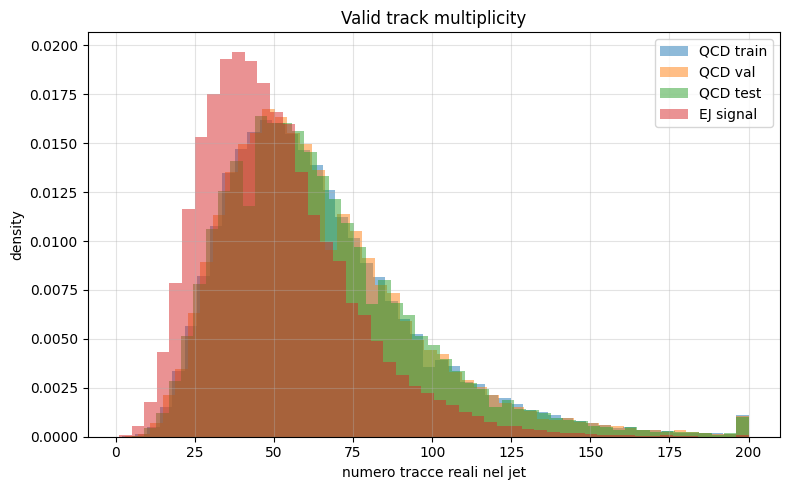

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(mask_train.sum(axis=1), bins=50, alpha=0.5, density=True, label='QCD train')
plt.hist(mask_val.sum(axis=1), bins=50, alpha=0.5, density=True, label='QCD val')
plt.hist(mask_bkg_test.sum(axis=1), bins=50, alpha=0.5, density=True, label='QCD test')
plt.hist(mask_sig.sum(axis=1), bins=50, alpha=0.5, density=True, label='EJ signal')
plt.xlabel('numero tracce reali nel jet')
plt.ylabel('density')
plt.title('Valid track multiplicity')
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'valid_track_multiplicity.png', dpi=200)
plt.show()

## 8. Dataset e DataLoader

In [9]:
class JetTrackSetDataset(Dataset):
    def __init__(self, X_jets, X_tracks, mask):
        self.X_jets = torch.from_numpy(np.asarray(X_jets, dtype=np.float32))
        self.X_tracks = torch.from_numpy(np.asarray(X_tracks, dtype=np.float32))
        self.mask = torch.from_numpy(np.asarray(mask)).bool()
    def __len__(self):
        return self.X_jets.shape[0]
    def __getitem__(self, idx):
        return self.X_jets[idx], self.X_tracks[idx], self.mask[idx]


def make_loader(X_jets, X_tracks, mask, batch_size, shuffle=False):
    return DataLoader(
        JetTrackSetDataset(X_jets, X_tracks, mask),
        batch_size=int(batch_size),
        shuffle=shuffle,
        num_workers=0,
        pin_memory=False,
        drop_last=False,
    )

## 9. Transformer Set Encoder - mean pooling + max pooling

In [10]:
class TransformerSetEncoder(nn.Module):
    def __init__(self, n_track_features, n_jet_features, d_model=128, n_heads=8, n_layers=4, dim_feedforward=512, latent_dim=64, dropout=0.07):
        super().__init__()
        self.n_track_features = int(n_track_features)
        self.n_jet_features = int(n_jet_features)
        self.d_model = int(d_model)
        self.latent_dim = int(latent_dim)

        self.track_embed = nn.Sequential(
            nn.Linear(n_track_features, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        if n_jet_features > 0:
            self.jet_encoder = nn.Sequential(
                nn.Linear(n_jet_features, d_model),
                nn.LayerNorm(d_model),
                nn.GELU(),
                nn.Dropout(dropout),
            )
            pooled_dim = 3 * d_model
        else:
            self.jet_encoder = None
            pooled_dim = 2 * d_model

        self.output = nn.Sequential(
            nn.Linear(pooled_dim, 2 * d_model),
            nn.LayerNorm(2 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(2 * d_model, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, latent_dim),
        )

    def forward(self, x_jets, x_tracks, mask):
        # mask: True = traccia reale, False = padding.
        h = self.track_embed(x_tracks)
        h = self.transformer(h, src_key_padding_mask=~mask)

        mask_f = mask.unsqueeze(-1).float()
        valid_counts = mask_f.sum(dim=1).clamp_min(1.0)
        mean_pool = (h * mask_f).sum(dim=1) / valid_counts

        h_for_max = h.masked_fill(~mask.unsqueeze(-1), -1e9)
        max_pool = h_for_max.max(dim=1).values
        max_pool = torch.where(torch.isfinite(max_pool), max_pool, torch.zeros_like(max_pool))

        pooled = [mean_pool, max_pool]
        if self.jet_encoder is not None:
            pooled.append(self.jet_encoder(x_jets))
        return self.output(torch.cat(pooled, dim=1))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 10. Utility Deep SVDD

In [11]:
@torch.no_grad()
def compute_center(model, loader, eps=1e-6):
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    model.eval()
    sum_z = None
    n_total = 0
    for x_jets, x_tracks, mask in loader:
        x_jets = x_jets.to(device)
        x_tracks = x_tracks.to(device)
        mask = mask.to(device)
        z = model(x_jets, x_tracks, mask)
        if sum_z is None:
            sum_z = torch.zeros(z.shape[1], device=device)
        sum_z += z.sum(dim=0)
        n_total += z.shape[0]
    center = sum_z / max(n_total, 1)
    center[(torch.abs(center) < eps) & (center < 0)] = -eps
    center[(torch.abs(center) < eps) & (center >= 0)] = eps
    return center


def svdd_loss(z, center):
    dist2 = torch.sum((z - center.unsqueeze(0)) ** 2, dim=1)
    return dist2.mean(), dist2


@torch.no_grad()
def evaluate_svdd_loss(model, loader, center):
    model.eval()
    total_loss = 0.0
    total_items = 0
    for x_jets, x_tracks, mask in loader:
        x_jets = x_jets.to(device)
        x_tracks = x_tracks.to(device)
        mask = mask.to(device)
        z = model(x_jets, x_tracks, mask)
        loss, _ = svdd_loss(z, center)
        bs = x_jets.shape[0]
        total_loss += loss.item() * bs
        total_items += bs
    return total_loss / max(total_items, 1)


@torch.no_grad()
def compute_scores_and_embeddings(model, X_jets, X_tracks, mask, center, batch_size=None):
    if batch_size is None:
        batch_size = SCORE_BATCH_CAP
    loader = make_loader(X_jets, X_tracks, mask, batch_size=batch_size, shuffle=False)
    model.eval()
    scores = []
    embeddings = []
    for x_jets, x_tracks, mask_batch in loader:
        x_jets = x_jets.to(device)
        x_tracks = x_tracks.to(device)
        mask_batch = mask_batch.to(device)
        z = model(x_jets, x_tracks, mask_batch)
        dist2 = torch.sum((z - center.unsqueeze(0)) ** 2, dim=1)
        scores.append(dist2.detach().cpu().numpy())
        embeddings.append(z.detach().cpu().numpy())
    return np.concatenate(scores), np.concatenate(embeddings, axis=0)


def latent_diagnostics(Z_train, scores_train, scores_val, scores_test, scores_sig):
    out = {
        'latent_std_mean': float(np.mean(np.std(Z_train, axis=0))),
        'latent_std_min': float(np.min(np.std(Z_train, axis=0))),
        'score_std_train': float(np.std(scores_train)),
        'score_std_val': float(np.std(scores_val)),
        'score_std_test': float(np.std(scores_test)),
        'score_std_sig': float(np.std(scores_sig)),
    }
    print('\nLatent/score diagnostics:')
    for k, v in out.items():
        print(f'{k:18s}: {v}')
    if out['latent_std_mean'] < 1e-3 or out['score_std_test'] < 1e-8:
        print('[WARN] possibile collasso Deep SVDD: latent o score quasi costanti.')
    return out

## 11. Quick hyperparameter tuning Transformer

In [12]:
TUNE_MAX_TRAIN = 8_000
TUNE_MAX_VAL = 4_000
TUNE_EPOCHS = 10
TUNE_PATIENCE = 3

CANDIDATE_CONFIGS = [
    {'d_model': 96, 'n_heads': 4, 'n_layers': 3, 'dim_feedforward': 384, 'latent_dim': 32, 'dropout': 0.05, 'lr': 1.0e-4, 'weight_decay': 1e-5, 'batch_size': 64},
    {'d_model': 128, 'n_heads': 4, 'n_layers': 3, 'dim_feedforward': 512, 'latent_dim': 32, 'dropout': 0.05, 'lr': 8.0e-5, 'weight_decay': 2e-5, 'batch_size': 64},
    {'d_model': 128, 'n_heads': 8, 'n_layers': 4, 'dim_feedforward': 512, 'latent_dim': 64, 'dropout': 0.07, 'lr': 7.0e-5, 'weight_decay': 2e-5, 'batch_size': 48},
    {'d_model': 160, 'n_heads': 8, 'n_layers': 4, 'dim_feedforward': 640, 'latent_dim': 64, 'dropout': 0.08, 'lr': 5.0e-5, 'weight_decay': 3e-5, 'batch_size': 32},
    {'d_model': 192, 'n_heads': 8, 'n_layers': 4, 'dim_feedforward': 768, 'latent_dim': 96, 'dropout': 0.10, 'lr': 4.0e-5, 'weight_decay': 5e-5, 'batch_size': 24},
]

FALLBACK_TRANSFORMER_CONFIG = {'d_model': 128, 'n_heads': 8, 'n_layers': 4, 'dim_feedforward': 512, 'latent_dim': 64, 'dropout': 0.07, 'lr': 7e-5, 'weight_decay': 2e-5, 'batch_size': 48}


def _subsample_triplet(Xj, Xt, M, max_n, seed):
    if max_n is None or len(Xj) <= max_n:
        return Xj, Xt, M
    rr = np.random.default_rng(seed)
    idx = rr.choice(len(Xj), size=max_n, replace=False)
    return Xj[idx], Xt[idx], M[idx]

Xj_tune_train, Xt_tune_train, M_tune_train = _subsample_triplet(X_jets_train, X_tracks_train, mask_train, TUNE_MAX_TRAIN, SEED)
Xj_tune_val, Xt_tune_val, M_tune_val = _subsample_triplet(X_jets_val, X_tracks_val, mask_val, TUNE_MAX_VAL, SEED + 1)
print('Tuning train:', Xj_tune_train.shape, Xt_tune_train.shape)
print('Tuning val  :', Xj_tune_val.shape, Xt_tune_val.shape)


def safe_batch_size(x):
    return int(min(int(x), TUNE_BATCH_CAP))


def make_tune_loader(Xj, Xt, M, batch_size, shuffle=False):
    return make_loader(Xj, Xt, M, batch_size=safe_batch_size(batch_size), shuffle=shuffle)


@torch.no_grad()
def tune_scores_and_latents(model, loader, center):
    scores = []
    latents = []
    model.eval()
    for x_jets, x_tracks, mask in loader:
        x_jets = x_jets.to(device)
        x_tracks = x_tracks.to(device)
        mask = mask.to(device)
        z = model(x_jets, x_tracks, mask)
        score = torch.sum((z - center.unsqueeze(0)) ** 2, dim=1)
        scores.append(score.detach().cpu().numpy())
        latents.append(z.detach().cpu().numpy())
    return np.concatenate(scores), np.concatenate(latents, axis=0)


def tune_one_transformer_config(cfg, config_id):
    print('\n' + '=' * 90)
    print(f'TRANSFORMER CONFIG {config_id}/{len(CANDIDATE_CONFIGS)}')
    print(cfg)
    batch_size = safe_batch_size(cfg['batch_size'])
    train_l = make_tune_loader(Xj_tune_train, Xt_tune_train, M_tune_train, batch_size, shuffle=True)
    val_l = make_tune_loader(Xj_tune_val, Xt_tune_val, M_tune_val, batch_size, shuffle=False)
    center_l = make_tune_loader(Xj_tune_train, Xt_tune_train, M_tune_train, min(batch_size, CENTER_BATCH_CAP), shuffle=False)

    model_tune = TransformerSetEncoder(n_track_features, n_jet_features, int(cfg['d_model']), int(cfg['n_heads']), int(cfg['n_layers']), int(cfg['dim_feedforward']), int(cfg['latent_dim']), float(cfg['dropout'])).to(device)
    n_params = count_params(model_tune)
    center_local = compute_center(model_tune, center_l)
    optimizer_tune = torch.optim.AdamW(model_tune.parameters(), lr=float(cfg['lr']), weight_decay=float(cfg['weight_decay']))
    scheduler_tune = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_tune, mode='min', factor=0.5, patience=1)

    best_val = np.inf
    best_state = None
    best_epoch = -1
    epochs_without_improvement = 0
    for epoch in range(1, TUNE_EPOCHS + 1):
        model_tune.train()
        train_losses = []
        for x_jets, x_tracks, mask in train_l:
            x_jets = x_jets.to(device)
            x_tracks = x_tracks.to(device)
            mask = mask.to(device)
            optimizer_tune.zero_grad(set_to_none=True)
            z = model_tune(x_jets, x_tracks, mask)
            loss, _ = svdd_loss(z, center_local)
            if not torch.isfinite(loss):
                raise RuntimeError('Tuning loss non finita.')
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_tune.parameters(), max_norm=5.0)
            optimizer_tune.step()
            train_losses.append(loss.item())
        train_loss = float(np.mean(train_losses))
        val_loss = evaluate_svdd_loss(model_tune, val_l, center_local)
        scheduler_tune.step(val_loss)
        print(f'epoch {epoch:02d}/{TUNE_EPOCHS} | train={train_loss:.6f} | val={val_loss:.6f} | best={best_val:.6f}')
        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model_tune.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= TUNE_PATIENCE:
            print('early stopping tuning')
            break

    if best_state is not None:
        model_tune.load_state_dict(best_state)
    train_loss_final = evaluate_svdd_loss(model_tune, train_l, center_local)
    val_loss_final = evaluate_svdd_loss(model_tune, val_l, center_local)
    train_scores, train_latents = tune_scores_and_latents(model_tune, train_l, center_local)
    val_scores, val_latents = tune_scores_and_latents(model_tune, val_l, center_local)

    y_bg = np.concatenate([np.zeros(len(train_scores), dtype=np.int64), np.ones(len(val_scores), dtype=np.int64)])
    s_bg = np.concatenate([train_scores, val_scores])
    bg_auc = roc_auc_score(y_bg, s_bg)
    bg_auc_inv = roc_auc_score(y_bg, -s_bg)
    bg_auc_best = max(bg_auc, bg_auc_inv)
    latent_std_mean = float(np.mean(np.std(train_latents, axis=0)))
    latent_std_min = float(np.min(np.std(train_latents, axis=0)))
    gap = max(0.0, val_loss_final - train_loss_final)
    bg_penalty = max(0.0, bg_auc_best - 0.55) * max(val_loss_final, 1e-8)
    gap_penalty = 0.30 * gap
    collapse_penalty = 0.0 if latent_std_mean >= 1e-3 else 10.0 * max(val_loss_final, 1e-8)
    selection_score = best_val + bg_penalty + gap_penalty + collapse_penalty

    result = {'config_id': int(config_id), **cfg, 'batch_size': int(batch_size), 'n_params': int(n_params), 'best_epoch': int(best_epoch), 'train_loss': float(train_loss_final), 'val_loss': float(val_loss_final), 'generalization_gap': float(gap), 'bg_auc_train_vs_val': float(bg_auc), 'bg_auc_train_vs_val_inverted': float(bg_auc_inv), 'bg_auc_train_vs_val_best': float(bg_auc_best), 'latent_std_mean': float(latent_std_mean), 'latent_std_min': float(latent_std_min), 'selection_score': float(selection_score)}
    del model_tune
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result

if RUN_TRANSFORMER_HPARAM_TUNING:
    transformer_tuning_rows = []
    for i, cfg in enumerate(CANDIDATE_CONFIGS, start=1):
        try:
            transformer_tuning_rows.append(tune_one_transformer_config(cfg, i))
        except RuntimeError as e:
            msg = str(e).lower()
            if 'cuda' in msg or 'out of memory' in msg:
                print('\n[CUDA ERROR] Riavvia il kernel e riduci TUNE_BATCH_CAP oppure usa meno configurazioni.')
                raise
            print(f'[SKIP CONFIG {i}] RuntimeError: {e}')
        except Exception as e:
            print(f'[SKIP CONFIG {i}] {type(e).__name__}: {e}')
        finally:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    transformer_tuning_results_df = pd.DataFrame(transformer_tuning_rows)
    if transformer_tuning_results_df.empty or 'selection_score' not in transformer_tuning_results_df.columns:
        print('\n[WARN] Nessuna configurazione valida. Uso fallback.')
        BEST_TRANSFORMER_CONFIG = FALLBACK_TRANSFORMER_CONFIG.copy()
    else:
        transformer_tuning_results_df = transformer_tuning_results_df.sort_values('selection_score', ascending=True).reset_index(drop=True)
        display(transformer_tuning_results_df)
        transformer_tuning_results_df.to_csv(OUTPUT_DIR / 'transformer_deep_svdd_hparam_tuning.csv', index=False)
        print('Saved:', OUTPUT_DIR / 'transformer_deep_svdd_hparam_tuning.csv')
        BEST_TRANSFORMER_CONFIG = transformer_tuning_results_df.iloc[0].to_dict()
else:
    BEST_TRANSFORMER_CONFIG = FALLBACK_TRANSFORMER_CONFIG.copy()

print('\n' + '=' * 90)
print('BEST_TRANSFORMER_CONFIG')
print(BEST_TRANSFORMER_CONFIG)

Tuning train: (8000, 15) (8000, 200, 16)
Tuning val  : (4000, 15) (4000, 200, 16)

TRANSFORMER CONFIG 1/5
{'d_model': 96, 'n_heads': 4, 'n_layers': 3, 'dim_feedforward': 384, 'latent_dim': 32, 'dropout': 0.05, 'lr': 0.0001, 'weight_decay': 1e-05, 'batch_size': 64}
epoch 01/10 | train=0.277921 | val=0.006818 | best=inf
epoch 02/10 | train=0.106579 | val=0.002805 | best=0.006818
epoch 03/10 | train=0.072654 | val=0.001585 | best=0.002805
epoch 04/10 | train=0.055015 | val=0.000979 | best=0.001585
epoch 05/10 | train=0.044509 | val=0.001200 | best=0.000979
epoch 06/10 | train=0.037100 | val=0.000657 | best=0.000979
epoch 07/10 | train=0.031669 | val=0.000975 | best=0.000657
epoch 08/10 | train=0.027780 | val=0.000686 | best=0.000657
epoch 09/10 | train=0.025232 | val=0.000477 | best=0.000657
epoch 10/10 | train=0.023699 | val=0.000307 | best=0.000477

TRANSFORMER CONFIG 2/5
{'d_model': 128, 'n_heads': 4, 'n_layers': 3, 'dim_feedforward': 512, 'latent_dim': 32, 'dropout': 0.05, 'lr': 8e-05

,config_id,d_model,n_heads,n_layers,dim_feedforward,latent_dim,dropout,lr,weight_decay,batch_size,n_params,best_epoch,train_loss,val_loss,generalization_gap,bg_auc_train_vs_val,bg_auc_train_vs_val_inverted,bg_auc_train_vs_val_best,latent_std_mean,latent_std_min,selection_score
0,1,96,4,3,384,32,0.05,0.00010,0.00001,64,416768,10,0.000307,0.000307,0.000000,0.494494,0.505506,0.505506,0.001918,0.001490,0.000307
1,2,128,4,3,512,32,0.05,0.00008,0.00002,64,735904,8,0.000324,0.000329,0.000004,0.513292,0.486708,0.513292,0.002389,0.001943,0.000330
2,3,128,8,4,512,64,0.07,0.00007,0.00002,48,938304,9,0.000838,0.000846,0.000008,0.508111,0.491889,0.508111,0.001540,0.001188,0.000849
3,4,160,8,4,640,64,0.08,0.00005,0.00003,32,1459584,9,0.000969,0.000970,0.000001,0.500255,0.499745,0.500255,0.001378,0.001047,0.000970
4,5,192,8,4,768,96,0.10,0.00004,0.00005,24,2101728,9,0.000646,0.000645,0.000000,0.495859,0.504141,0.504141,0.000916,0.000671,0.007096


Saved: ..\outputs\transformer_deep_svdd\transformer_deep_svdd_hparam_tuning.csv

BEST_TRANSFORMER_CONFIG
{'config_id': 1.0, 'd_model': 96.0, 'n_heads': 4.0, 'n_layers': 3.0, 'dim_feedforward': 384.0, 'latent_dim': 32.0, 'dropout': 0.05, 'lr': 0.0001, 'weight_decay': 1e-05, 'batch_size': 64.0, 'n_params': 416768.0, 'best_epoch': 10.0, 'train_loss': 0.000307324209716171, 'val_loss': 0.0003066729095298797, 'generalization_gap': 0.0, 'bg_auc_train_vs_val': 0.49449426562500004, 'bg_auc_train_vs_val_inverted': 0.505505734375, 'bg_auc_train_vs_val_best': 0.505505734375, 'latent_std_mean': 0.001918151043355465, 'latent_std_min': 0.0014904681593179703, 'selection_score': 0.0003066729095298797}


## 12. Plot tuning Transformer - safe

,config_id,d_model,n_heads,n_layers,dim_feedforward,latent_dim,dropout,lr,weight_decay,batch_size,n_params,best_epoch,train_loss,val_loss,generalization_gap,bg_auc_train_vs_val,bg_auc_train_vs_val_inverted,bg_auc_train_vs_val_best,latent_std_mean,latent_std_min,selection_score
0,1,96,4,3,384,32,0.05,0.00010,0.00001,64,416768,10,0.000307,0.000307,0.000000,0.494494,0.505506,0.505506,0.001918,0.001490,0.000307
1,2,128,4,3,512,32,0.05,0.00008,0.00002,64,735904,8,0.000324,0.000329,0.000004,0.513292,0.486708,0.513292,0.002389,0.001943,0.000330
2,3,128,8,4,512,64,0.07,0.00007,0.00002,48,938304,9,0.000838,0.000846,0.000008,0.508111,0.491889,0.508111,0.001540,0.001188,0.000849
3,4,160,8,4,640,64,0.08,0.00005,0.00003,32,1459584,9,0.000969,0.000970,0.000001,0.500255,0.499745,0.500255,0.001378,0.001047,0.000970
4,5,192,8,4,768,96,0.10,0.00004,0.00005,24,2101728,9,0.000646,0.000645,0.000000,0.495859,0.504141,0.504141,0.000916,0.000671,0.007096


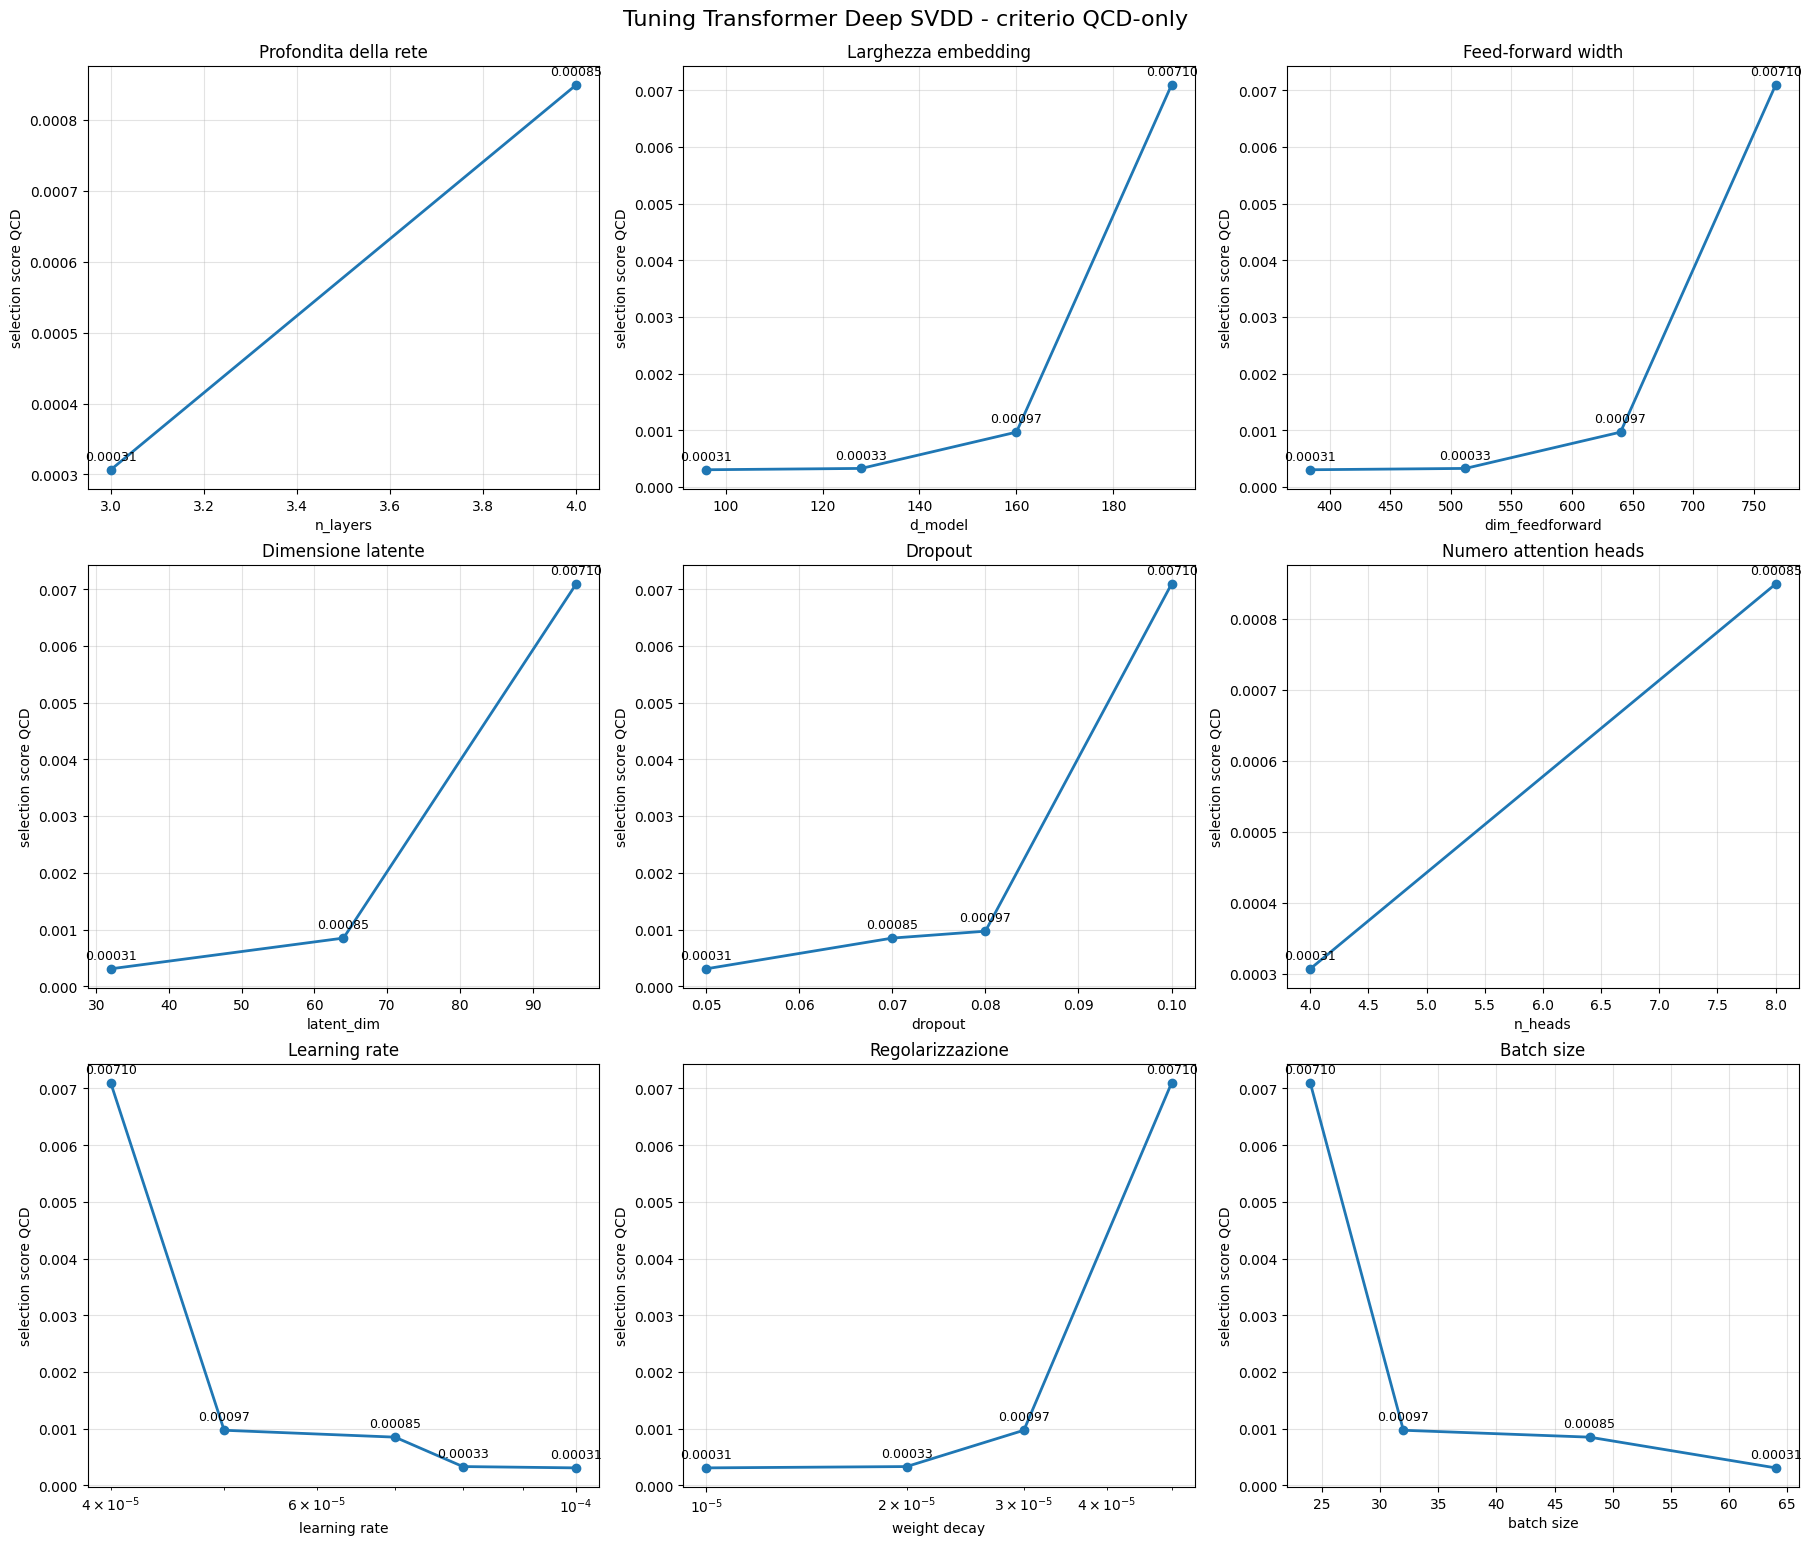

Salvato: ..\outputs\transformer_deep_svdd\plots\transformer_deep_svdd_hparam_elbow_plots.png


In [13]:
try:
    df_tf_tune = transformer_tuning_results_df.copy()
except NameError:
    try:
        df_tf_tune = pd.read_csv(OUTPUT_DIR / 'transformer_deep_svdd_hparam_tuning.csv')
    except Exception:
        df_tf_tune = pd.DataFrame()

Y_COL = 'selection_score'
Y_LABEL = 'selection score QCD'

if df_tf_tune.empty or Y_COL not in df_tf_tune.columns:
    print('[SKIP] Nessun risultato valido di tuning da plottare.')
    print('BEST_TRANSFORMER_CONFIG usata:')
    display(pd.DataFrame([BEST_TRANSFORMER_CONFIG]))
else:
    display(df_tf_tune.sort_values(Y_COL).reset_index(drop=True))
    def best_by_param(data, param):
        return data.dropna(subset=[param, Y_COL]).groupby(param, as_index=False)[Y_COL].min().sort_values(param).reset_index(drop=True)
    def plot_line_with_labels(ax, x, y, xlabel, title, logx=False):
        ax.plot(x, y, marker='o', linewidth=2)
        for xi, yi in zip(x, y):
            ax.annotate(f'{yi:.5f}', xy=(xi, yi), xytext=(0, 7), textcoords='offset points', ha='center', fontsize=9)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(Y_LABEL)
        ax.set_title(title)
        ax.grid(True, alpha=0.35)
        if logx:
            ax.set_xscale('log')
    plot_specs = [
        ('n_layers','n_layers','Profondita della rete',False),
        ('d_model','d_model','Larghezza embedding',False),
        ('dim_feedforward','dim_feedforward','Feed-forward width',False),
        ('latent_dim','latent_dim','Dimensione latente',False),
        ('dropout','dropout','Dropout',False),
        ('n_heads','n_heads','Numero attention heads',False),
        ('lr','learning rate','Learning rate',True),
        ('weight_decay','weight decay','Regolarizzazione',True),
        ('batch_size','batch size','Batch size',False),
    ]
    plot_specs = [spec for spec in plot_specs if spec[0] in df_tf_tune.columns]
    if not plot_specs:
        print('[SKIP] Nessuna colonna plottabile.')
    else:
        ncols = 3
        nrows = math.ceil(len(plot_specs) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows), constrained_layout=True)
        axes = np.array(axes).reshape(-1)
        fig.suptitle('Tuning Transformer Deep SVDD - criterio QCD-only', fontsize=16, y=1.02)
        for ax, (param, xlabel, title, logx) in zip(axes, plot_specs):
            g = best_by_param(df_tf_tune, param)
            if g.empty:
                ax.axis('off')
                continue
            plot_line_with_labels(ax, g[param], g[Y_COL], xlabel, title, logx=logx)
        for ax in axes[len(plot_specs):]:
            ax.axis('off')
        out_path_plot = PLOTS_DIR / 'transformer_deep_svdd_hparam_elbow_plots.png'
        plt.savefig(out_path_plot, dpi=200, bbox_inches='tight')
        plt.show()
        print('Salvato:', out_path_plot)

## 13. Creazione modello finale

In [14]:
D_MODEL = int(BEST_TRANSFORMER_CONFIG['d_model'])
N_HEADS = int(BEST_TRANSFORMER_CONFIG['n_heads'])
N_LAYERS = int(BEST_TRANSFORMER_CONFIG['n_layers'])
DIM_FEEDFORWARD = int(BEST_TRANSFORMER_CONFIG['dim_feedforward'])
LATENT_DIM = int(BEST_TRANSFORMER_CONFIG['latent_dim'])
DROPOUT = float(BEST_TRANSFORMER_CONFIG['dropout'])
LR = float(BEST_TRANSFORMER_CONFIG['lr'])
WEIGHT_DECAY = float(BEST_TRANSFORMER_CONFIG['weight_decay'])
BATCH_SIZE = min(int(BEST_TRANSFORMER_CONFIG['batch_size']), FINAL_BATCH_CAP)
CENTER_BATCH_SIZE = min(BATCH_SIZE, CENTER_BATCH_CAP)
SCORE_BATCH_SIZE = min(max(BATCH_SIZE, 32), SCORE_BATCH_CAP)
N_EPOCHS = N_EPOCHS_FINAL
PATIENCE = PATIENCE_FINAL

train_loader = make_loader(X_jets_train, X_tracks_train, mask_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_jets_val, X_tracks_val, mask_val, batch_size=BATCH_SIZE, shuffle=False)
center_loader = make_loader(X_jets_train, X_tracks_train, mask_train, batch_size=CENTER_BATCH_SIZE, shuffle=False)

model = TransformerSetEncoder(n_track_features, n_jet_features, D_MODEL, N_HEADS, N_LAYERS, DIM_FEEDFORWARD, LATENT_DIM, DROPOUT).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(model)
print('Parameters:', count_params(model))
print('\nFinal config:')
print('D_MODEL        =', D_MODEL)
print('N_HEADS        =', N_HEADS)
print('N_LAYERS       =', N_LAYERS)
print('DIM_FEEDFORWARD=', DIM_FEEDFORWARD)
print('LATENT_DIM     =', LATENT_DIM)
print('DROPOUT        =', DROPOUT)
print('LR             =', LR)
print('WEIGHT_DECAY   =', WEIGHT_DECAY)
print('BATCH_SIZE     =', BATCH_SIZE)
print('CENTER_BATCH   =', CENTER_BATCH_SIZE)
print('SCORE_BATCH    =', SCORE_BATCH_SIZE)
print('N_EPOCHS       =', N_EPOCHS)
print('PATIENCE       =', PATIENCE)
print('Train batches  =', len(train_loader))
print('Val batches    =', len(val_loader))

TransformerSetEncoder(
  (track_embed): Sequential(
    (0): Linear(in_features=16, out_features=96, bias=True)
    (1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.05, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=384, bias=True)
        (dropout): Dropout(p=0.05, inplace=False)
        (linear2): Linear(in_features=384, out_features=96, bias=True)
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.05, inplace=False)
        (dropout2): Dropout(p=0.05, inplace=False)
      )
    )
  )
  (jet_encoder): Sequential(
    (0): Line

## 14. Inizializzazione centro SVDD

In [15]:
center = compute_center(model, center_loader)
print('center shape:', center.shape)
print('center mean/std:', center.mean().item(), center.std().item())
print('center min/max:', center.min().item(), center.max().item())

center shape: torch.Size([32])
center mean/std: -0.0006431695073843002 0.3117591440677643
center min/max: -0.7038378119468689 0.6273952722549438


## 15. Training Deep SVDD

In [16]:
train_losses = []
val_losses = []
lr_history = []
best_val_loss = np.inf
best_epoch = -1
best_state_dict = None
epochs_without_improvement = 0
start_time = time.time()

for epoch in range(N_EPOCHS):
    model.train()
    total_loss = 0.0
    total_items = 0
    for x_jets, x_tracks, mask in train_loader:
        x_jets = x_jets.to(device)
        x_tracks = x_tracks.to(device)
        mask = mask.to(device)
        optimizer.zero_grad(set_to_none=True)
        z = model(x_jets, x_tracks, mask)
        loss, _ = svdd_loss(z, center)
        if not torch.isfinite(loss):
            raise RuntimeError('Loss non finita.')
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        bs = x_jets.shape[0]
        total_loss += loss.item() * bs
        total_items += bs
    train_loss = total_loss / max(total_items, 1)
    val_loss = evaluate_svdd_loss(model, val_loader, center)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lr_history.append(current_lr)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    elapsed_min = (time.time() - start_time) / 60.0
    print(f'Epoch {epoch+1:03d}/{N_EPOCHS} | train={train_loss:.6f} | val={val_loss:.6f} | best={best_val_loss:.6f} @ {best_epoch} | lr={current_lr:.2e} | elapsed={elapsed_min:.1f} min')
    if epochs_without_improvement >= PATIENCE:
        print('Early stopping.')
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f'Loaded best model from epoch {best_epoch} with val loss={best_val_loss:.6f}')

df_history = pd.DataFrame({'epoch': np.arange(1, len(train_losses) + 1), 'train_svdd_loss': train_losses, 'val_svdd_loss': val_losses, 'lr': lr_history})
df_history.to_csv(OUTPUT_DIR / 'transformer_deep_svdd_training_history.csv', index=False)
print('Saved:', OUTPUT_DIR / 'transformer_deep_svdd_training_history.csv')

Epoch 001/100 | train=0.057020 | val=0.000376 | best=0.000376 @ 1 | lr=1.00e-04 | elapsed=1.1 min
Epoch 002/100 | train=0.007842 | val=0.000139 | best=0.000139 @ 2 | lr=1.00e-04 | elapsed=2.2 min
Epoch 003/100 | train=0.003753 | val=0.000169 | best=0.000139 @ 2 | lr=1.00e-04 | elapsed=3.3 min
Epoch 004/100 | train=0.002342 | val=0.000082 | best=0.000082 @ 4 | lr=1.00e-04 | elapsed=4.4 min
Epoch 005/100 | train=0.001623 | val=0.000017 | best=0.000017 @ 5 | lr=1.00e-04 | elapsed=5.5 min
Epoch 006/100 | train=0.001179 | val=0.000009 | best=0.000009 @ 6 | lr=1.00e-04 | elapsed=6.6 min
Epoch 007/100 | train=0.000909 | val=0.000012 | best=0.000009 @ 6 | lr=1.00e-04 | elapsed=7.7 min
Epoch 008/100 | train=0.000734 | val=0.000035 | best=0.000009 @ 6 | lr=1.00e-04 | elapsed=8.8 min
Epoch 009/100 | train=0.000603 | val=0.000010 | best=0.000009 @ 6 | lr=1.00e-04 | elapsed=9.9 min
Epoch 010/100 | train=0.000510 | val=0.000010 | best=0.000009 @ 6 | lr=1.00e-04 | elapsed=11.0 min
Epoch 011/100 | tra

KeyboardInterrupt: 

## 16. Training plots

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df_history['epoch'], df_history['train_svdd_loss'], label='train QCD')
plt.plot(df_history['epoch'], df_history['val_svdd_loss'], label='val QCD')
plt.xlabel('epoch')
plt.ylabel('SVDD loss')
plt.title('Transformer Deep SVDD training')
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'transformer_deep_svdd_training_loss.png', dpi=200)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df_history['epoch'], df_history['lr'])
plt.xlabel('epoch')
plt.ylabel('learning rate')
plt.title('Learning rate schedule')
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'transformer_deep_svdd_learning_rate.png', dpi=200)
plt.show()

## 17. Calcolo score SVDD

In [ ]:
scores_train, Z_train = compute_scores_and_embeddings(model, X_jets_train, X_tracks_train, mask_train, center, batch_size=SCORE_BATCH_SIZE)
scores_val, Z_val = compute_scores_and_embeddings(model, X_jets_val, X_tracks_val, mask_val, center, batch_size=SCORE_BATCH_SIZE)
scores_bkg_test, Z_bkg_test = compute_scores_and_embeddings(model, X_jets_bkg_test, X_tracks_bkg_test, mask_bkg_test, center, batch_size=SCORE_BATCH_SIZE)
scores_sig, Z_sig = compute_scores_and_embeddings(model, X_jets_sig, X_tracks_sig, mask_sig, center, batch_size=SCORE_BATCH_SIZE)

for name, s in [('train QCD', scores_train), ('val QCD', scores_val), ('test QCD', scores_bkg_test), ('signal EJ', scores_sig)]:
    print(name, 'mean', float(np.mean(s)), 'std', float(np.std(s)), 'q', np.percentile(s, [1, 50, 99]))

diagnostics = latent_diagnostics(Z_train, scores_train, scores_val, scores_bkg_test, scores_sig)

## 18. ROC/AUC e metriche a mistag fissato

In [ ]:
def orient_scores(bg, sig):
    bg = np.asarray(bg, dtype=np.float64)
    sig = np.asarray(sig, dtype=np.float64)
    y = np.concatenate([np.zeros(len(bg), dtype=np.int64), np.ones(len(sig), dtype=np.int64)])
    s = np.concatenate([bg, sig])
    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)
    if auc_inv > auc:
        return -bg, -sig, auc_inv, True, auc, auc_inv
    return bg, sig, auc, False, auc, auc_inv


def evaluate_scores(bg, sig, model_name='Transformer Deep SVDD', score_name='SVDD'):
    bg_o, sig_o, best_auc, flipped, auc, auc_inv = orient_scores(bg, sig)
    y = np.concatenate([np.zeros(len(bg_o), dtype=np.int64), np.ones(len(sig_o), dtype=np.int64)])
    s = np.concatenate([bg_o, sig_o])
    fpr, tpr, thresholds = roc_curve(y, s)
    rows = []
    for mistag in MISTAG_POINTS:
        threshold = np.quantile(bg_o, 1.0 - mistag)
        eff = np.mean(sig_o >= threshold)
        actual_mistag = np.mean(bg_o >= threshold)
        rows.append({'model': model_name, 'score': score_name, 'auc': best_auc, 'raw_auc': auc, 'auc_inverted': auc_inv, 'flipped': flipped, 'mistag_target': mistag, 'actual_mistag': actual_mistag, 'signal_efficiency': eff, 'threshold': threshold})
    return {'bg_oriented': bg_o, 'sig_oriented': sig_o, 'best_auc': best_auc, 'auc': auc, 'auc_inverted': auc_inv, 'flipped': flipped, 'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds, 'eff_table': pd.DataFrame(rows)}

eval_main = evaluate_scores(scores_bkg_test, scores_sig)
print('Raw AUC:', eval_main['auc'])
print('AUC inverted:', eval_main['auc_inverted'])
print('Best AUC:', eval_main['best_auc'])
print('Flipped:', eval_main['flipped'])
display(eval_main['eff_table'])

## 19. Plot ROC e distribuzioni score

In [ ]:
bg_o = eval_main['bg_oriented']
sig_o = eval_main['sig_oriented']

plt.figure(figsize=(7, 7))
plt.plot(eval_main['fpr'], eval_main['tpr'], label=f"Transformer Deep SVDD AUC={eval_main['best_auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.xlabel('QCD mistag rate')
plt.ylabel('Emerging Jets efficiency')
plt.title('ROC curve')
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'transformer_deep_svdd_roc.png', dpi=200)
plt.show()

all_scores = np.concatenate([bg_o, sig_o])
lo = np.percentile(all_scores, 0.1)
hi = np.percentile(all_scores, 99.5)
plt.figure(figsize=(8, 5))
plt.hist(bg_o, bins=100, range=(lo, hi), density=True, alpha=0.55, label='QCD test')
plt.hist(sig_o, bins=100, range=(lo, hi), density=True, alpha=0.55, label='EJ signal')
plt.yscale('log')
plt.xlabel('oriented SVDD score')
plt.ylabel('density')
plt.title('Transformer Deep SVDD score distribution')
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'transformer_deep_svdd_score_distribution.png', dpi=200)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(eval_main['eff_table']['mistag_target'], eval_main['eff_table']['signal_efficiency'], marker='o')
plt.xscale('log')
plt.gca().invert_xaxis()
plt.xlabel('QCD mistag target')
plt.ylabel('EJ signal efficiency')
plt.title('Signal efficiency at fixed QCD mistag')
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'transformer_deep_svdd_eff_vs_mistag.png', dpi=200)
plt.show()

## 20. Background consistency checks

In [ ]:
def bg_vs_bg_auc(a, b, name_a, name_b):
    y = np.concatenate([np.zeros(len(a), dtype=np.int64), np.ones(len(b), dtype=np.int64)])
    s = np.concatenate([a, b])
    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)
    return {'comparison': f'{name_a} vs {name_b}', 'auc': auc, 'auc_inverted': auc_inv, 'best_auc': max(auc, auc_inv)}

bg_checks = pd.DataFrame([
    bg_vs_bg_auc(scores_train, scores_val, 'train QCD', 'val QCD'),
    bg_vs_bg_auc(scores_train, scores_bkg_test, 'train QCD', 'test QCD'),
    bg_vs_bg_auc(scores_val, scores_bkg_test, 'val QCD', 'test QCD'),
])
display(bg_checks)

plt.figure(figsize=(8, 5))
plt.hist(scores_train, bins=100, density=True, alpha=0.45, label='train QCD')
plt.hist(scores_val, bins=100, density=True, alpha=0.45, label='val QCD')
plt.hist(scores_bkg_test, bins=100, density=True, alpha=0.45, label='test QCD')
plt.yscale('log')
plt.xlabel('SVDD score')
plt.ylabel('density')
plt.title('QCD score consistency')
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'transformer_deep_svdd_background_consistency.png', dpi=200)
plt.show()

## 21. Diagnostica supervisionata sugli embedding

In [ ]:
auc_latent_logreg = np.nan
if DO_LATENT_LOGISTIC_DIAGNOSTIC:
    n_bkg = len(Z_bkg_test)
    n_sig = len(Z_sig)
    n_each = min(n_bkg, n_sig, MAX_LATENT_DIAGNOSTIC_EVENTS)
    rr = np.random.default_rng(SEED)
    idx_b = rr.choice(n_bkg, size=n_each, replace=False)
    idx_s = rr.choice(n_sig, size=n_each, replace=False)
    X_lat = np.concatenate([Z_bkg_test[idx_b], Z_sig[idx_s]], axis=0)
    y_lat = np.concatenate([np.zeros(n_each, dtype=np.int64), np.ones(n_each, dtype=np.int64)])
    X_train_lat, X_test_lat, y_train_lat, y_test_lat = train_test_split(X_lat, y_lat, test_size=0.5, random_state=SEED, stratify=y_lat)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_lat)
    X_test_scaled = scaler.transform(X_test_lat)
    clf = LogisticRegression(max_iter=3000)
    clf.fit(X_train_scaled, y_train_lat)
    p = clf.predict_proba(X_test_scaled)[:, 1]
    auc_latent_logreg = roc_auc_score(y_test_lat, p)
    print('Latent logistic diagnostic AUC:', auc_latent_logreg)
    print('Nota: diagnostica supervisionata, non anomaly detection.')

## 22. Permutation invariance check

In [ ]:
def permutation_invariance_check(model, X_jets, X_tracks, mask, center, n_samples=512):
    model.eval()
    n_samples = min(n_samples, X_jets.shape[0])
    Xj = torch.from_numpy(X_jets[:n_samples]).float().to(device)
    Xt = torch.from_numpy(X_tracks[:n_samples]).float().to(device)
    M = torch.from_numpy(mask[:n_samples]).bool().to(device)
    B, N, F = Xt.shape
    perm = torch.stack([torch.randperm(N, device=device) for _ in range(B)], dim=0)
    perm_exp = perm.unsqueeze(-1).expand(B, N, F)
    Xt_perm = torch.gather(Xt, dim=1, index=perm_exp)
    M_perm = torch.gather(M, dim=1, index=perm)
    with torch.no_grad():
        z = model(Xj, Xt, M)
        z_p = model(Xj, Xt_perm, M_perm)
        dz = torch.mean(torch.abs(z - z_p)).item()
        score = torch.sum((z - center.unsqueeze(0)) ** 2, dim=1)
        score_p = torch.sum((z_p - center.unsqueeze(0)) ** 2, dim=1)
        dscore = torch.mean(torch.abs(score - score_p)).item()
    return {'mean_abs_delta_embedding': dz, 'mean_abs_delta_score': dscore}

if DO_PERMUTATION_INVARIANCE_CHECK:
    perm_check = permutation_invariance_check(model, X_jets_bkg_test, X_tracks_bkg_test, mask_bkg_test, center, n_samples=MAX_PERMUTATION_CHECK_EVENTS)
    print('Permutation invariance check:')
    print(perm_check)
else:
    perm_check = {'mean_abs_delta_embedding': np.nan, 'mean_abs_delta_score': np.nan}

## 23. Feature importance opzionale

In [ ]:
feature_importance_df = pd.DataFrame()
if DO_FEATURE_IMPORTANCE:
    n_b = min(len(X_jets_bkg_test), MAX_FEATURE_IMPORTANCE_EVENTS)
    n_s = min(len(X_jets_sig), MAX_FEATURE_IMPORTANCE_EVENTS)
    rr = np.random.default_rng(SEED)
    idx_b = rr.choice(len(X_jets_bkg_test), size=n_b, replace=False)
    idx_s = rr.choice(len(X_jets_sig), size=n_s, replace=False)
    base_auc = evaluate_scores(scores_bkg_test[idx_b], scores_sig[idx_s])['best_auc']
    rows = []
    for j, fname in enumerate(track_feature_names):
        Xt_b = X_tracks_bkg_test[idx_b].copy()
        Xt_s = X_tracks_sig[idx_s].copy()
        Xt_b[:, :, j] = Xt_b[rr.permutation(n_b), :, j]
        Xt_s[:, :, j] = Xt_s[rr.permutation(n_s), :, j]
        sb, _ = compute_scores_and_embeddings(model, X_jets_bkg_test[idx_b], Xt_b, mask_bkg_test[idx_b], center, batch_size=SCORE_BATCH_SIZE)
        ss, _ = compute_scores_and_embeddings(model, X_jets_sig[idx_s], Xt_s, mask_sig[idx_s], center, batch_size=SCORE_BATCH_SIZE)
        auc_perm = evaluate_scores(sb, ss)['best_auc']
        rows.append({'feature': fname, 'base_auc': base_auc, 'permuted_auc': auc_perm, 'delta_auc': base_auc - auc_perm})
        print(j, fname, 'delta_auc', base_auc - auc_perm)
    feature_importance_df = pd.DataFrame(rows).sort_values('delta_auc', ascending=False)
    feature_importance_df.to_csv(OUTPUT_DIR / 'transformer_deep_svdd_feature_importance.csv', index=False)
    display(feature_importance_df.head(20))
else:
    print('Feature importance disattivata. Imposta DO_FEATURE_IMPORTANCE=True se vuoi lanciarla.')

## 24. Salvataggio finale

In [ ]:
results_summary = {
    'model': 'Transformer Deep SVDD',
    'score': 'SVDD distance',
    'pooling': 'mean_max',
    'auc': float(eval_main['auc']),
    'auc_inverted': float(eval_main['auc_inverted']),
    'best_auc': float(eval_main['best_auc']),
    'flipped': bool(eval_main['flipped']),
    'auc_latent_logreg': float(auc_latent_logreg),
    'n_train': int(len(X_jets_train)),
    'n_val': int(len(X_jets_val)),
    'n_bkg_test': int(len(X_jets_bkg_test)),
    'n_signal': int(len(X_jets_sig)),
    'n_track_features': int(n_track_features),
    'n_jet_features': int(n_jet_features),
    'max_tracks': int(max_tracks),
    'd_model': int(D_MODEL),
    'n_heads': int(N_HEADS),
    'n_layers': int(N_LAYERS),
    'dim_feedforward': int(DIM_FEEDFORWARD),
    'latent_dim': int(LATENT_DIM),
    'dropout': float(DROPOUT),
    'learning_rate': float(LR),
    'weight_decay': float(WEIGHT_DECAY),
    'batch_size': int(BATCH_SIZE),
    'center_batch_size': int(CENTER_BATCH_SIZE),
    'score_batch_size': int(SCORE_BATCH_SIZE),
    'hparam_tuning_used': bool(RUN_TRANSFORMER_HPARAM_TUNING),
    'hparam_selection_score': float(BEST_TRANSFORMER_CONFIG.get('selection_score', np.nan)),
    'best_epoch': int(best_epoch),
    'best_val_loss': float(best_val_loss),
    'permutation_mean_abs_delta_embedding': float(perm_check['mean_abs_delta_embedding']),
    'permutation_mean_abs_delta_score': float(perm_check['mean_abs_delta_score']),
    **diagnostics,
}

for _, row in bg_checks.iterrows():
    key = row['comparison'].replace(' ', '_').replace('vs', 'VS')
    results_summary[f'{key}_best_auc'] = float(row['best_auc'])

best_config_json = {}
for k, v in BEST_TRANSFORMER_CONFIG.items():
    if isinstance(v, np.floating):
        best_config_json[k] = float(v)
    elif isinstance(v, np.integer):
        best_config_json[k] = int(v)
    else:
        best_config_json[k] = v

with open(OUTPUT_DIR / 'transformer_deep_svdd_config.json', 'w', encoding='utf-8') as f:
    json.dump({**results_summary, 'processed_path': str(PROCESSED_PATH), 'jet_feature_names': jet_feature_names, 'track_feature_names': track_feature_names, 'best_transformer_config': best_config_json}, f, indent=2)

eval_main['eff_table'].to_csv(OUTPUT_DIR / 'transformer_deep_svdd_results.csv', index=False)
bg_checks.to_csv(OUTPUT_DIR / 'transformer_deep_svdd_background_checks.csv', index=False)

torch.save({'model_state_dict': model.state_dict(), 'center': center.detach().cpu(), 'config': results_summary, 'jet_feature_names': jet_feature_names, 'track_feature_names': track_feature_names, 'train_losses': train_losses, 'val_losses': val_losses, 'lr_history': lr_history}, OUTPUT_DIR / 'transformer_deep_svdd_model.pt')

np.savez_compressed(
    OUTPUT_DIR / 'transformer_deep_svdd_scores.npz',
    scores_train=scores_train,
    scores_val=scores_val,
    scores_bkg_test=scores_bkg_test,
    scores_sig=scores_sig,
    Z_train=Z_train,
    Z_val=Z_val,
    Z_bkg_test=Z_bkg_test,
    Z_sig=Z_sig,
    center=center.detach().cpu().numpy(),
    bg_oriented=eval_main['bg_oriented'],
    sig_oriented=eval_main['sig_oriented'],
    fpr=eval_main['fpr'],
    tpr=eval_main['tpr'],
    thresholds=eval_main['thresholds'],
    jet_feature_names=np.array(jet_feature_names, dtype=object),
    track_feature_names=np.array(track_feature_names, dtype=object),
    auc=np.array(eval_main['auc'], dtype=np.float32),
    auc_inverted=np.array(eval_main['auc_inverted'], dtype=np.float32),
    best_auc=np.array(eval_main['best_auc'], dtype=np.float32),
    auc_latent_logreg=np.array(auc_latent_logreg, dtype=np.float32),
)

pd.DataFrame([results_summary]).to_csv(OUTPUT_DIR / 'transformer_deep_svdd_summary.csv', index=False)

print('Saved:')
print(OUTPUT_DIR / 'transformer_deep_svdd_model.pt')
print(OUTPUT_DIR / 'transformer_deep_svdd_scores.npz')
print(OUTPUT_DIR / 'transformer_deep_svdd_results.csv')
print(OUTPUT_DIR / 'transformer_deep_svdd_background_checks.csv')
print(OUTPUT_DIR / 'transformer_deep_svdd_config.json')
print(OUTPUT_DIR / 'transformer_deep_svdd_summary.csv')
print('plots:', PLOTS_DIR)

## 25. Note per la relazione

Questa versione e' il rollback pulito del Transformer Deep SVDD:

- 200 tracce padded;
- padding ignorato con mask;
- mean pooling + max pooling;
- tuning QCD-only;
- score finale = distanza quadratica dal centro SVDD.

Controlli da guardare dopo il run:

1. AUC QCD test vs EJ;
2. Efficienze a 10%, 1% e 0.1% QCD mistag;
3. background consistency QCD-vs-QCD vicino a 0.5;
4. `latent_std_mean` e `score_std_test` non vicini a zero;
5. permutation invariance check piccolo.